# APEC 8222 Final Project

Ram Prasad

12/17/2025

I replicate the paper “Why Should I Trust You?”, Explaining the Predictions of Any Classifier, by Ribeiro et al (Aug. 2016). https://arxiv.org/pdf/1602.04938


## Summary

A common criticism of modern machine-learning models is that they are effectively black boxes. Users may see inputs and outputs, but cannot understand why a particular prediction was made in the way one can with a linear regression. This lack of transparency matters because humans generally rely on models they trust. The paper distinguishes between two kinds of trust. First, trusting a prediction, meaning having enough confidence in a specific output to act on it. Second, trusting a model, meaning confidence that the model will behave reasonably when deployed more broadly. Explanations also serve a validation role. Test-set performance may not reflect real-world behavior due to dataset shift, leakage, or mismatched objectives, and inspecting explained predictions can reveal these failures when accuracy alone cannot.

In "'Why Should I Trust You?', Explaining the Predictions of Any Classifier', Ribeiro et al propose LIME (Local Interpretable Model-agnostic Explanations), a general solution to both trust problems. At the prediction level, LIME explains a single output by learning an interpretable model locally around the instance being predicted. At the model level, LIME can be applied to a set of representative instances (via SP-LIME) to give users a global sense of how the model behaves. Explanations are intrinsically useful. They help users validate predictions, diagnose spurious correlations, and even compare models that have similar test accuracy but rely on qualitatively different signals. For example, a classifier predicting “flu” may be explained by highlighting symptoms such as sneeze or headache with signed weights, allowing a human to judge whether the reasoning is sensible.

The paper formalizes explanations with three core requirements. First, interpretability (the explanation must be understandable to humans), second, local fidelity (it must accurately reflect the model’s behavior near the instance of interest), and third, model-agnosticism (it must apply to any classifier treated as a black box). LIME defines explanations as simple models fitted on perturbed versions of the original instance, weighted by proximity. The key idea is not to explain the model globally, but to approximate it well in a small neighborhood using a function that is interpretable.

## Model

Let $f : \mathbb{R}^d \rightarrow \mathbb{R}$ denote the black-box model,
where $f(x)$ is the prediction (e.g., class probability) for instance $x \in \mathbb{R}^d$. Each instance $x$ has an interpretable representation
$x' \in \{0,1\}^{d'}$, where $x'_j = 1$ indicates the presence of an
interpretable component (e.g., a word or superpixel), and $x'_j = 0$
its absence. In general, $d \neq d'$. An explanation is a model $g \in \mathcal{G}$, where $\mathcal{G}$ is a class of interpretable models (e.g., sparse linear models or shallow trees), defined over the interpretable space $\{0,1\}^{d'}$. Let $\pi_x(z)$ be a proximity function that measures how close an instance $z$ is to $x$, thereby defining locality around $x$. Typically,
$$
\pi_x(z) = \exp\left(-\frac{D(x,z)^2}{\sigma^2}\right),
$$
where $D(\cdot,\cdot)$ is a distance function and $\sigma$ controls the
kernel width. Define the locality-aware loss
$$
\mathcal{L}(f, g, \pi_x)
= \sum_{z \in \mathcal{Z}} \pi_x(z)\,\big(f(z) - g(z')\big)^2,
$$
where $\mathcal{Z}$ is a set of perturbed samples around $x$ and $z'$
is the interpretable representation of $z$. Let $\Omega(g)$ measure the complexity of $g$ (e.g., number of nonzero coefficients in a linear model). The LIME explanation for instance $x$ is defined as
$$
\xi(x) = \arg\min_{g \in \mathcal{G}}
\; \mathcal{L}(f, g, \pi_x) + \Omega(g).
$$
The paper focuses on linear models,
$$
g(z') = w_g^\top z',
\qquad
\Omega(g) = \infty \cdot \mathbb{I}\big(\|w_g\|_0 > K\big),
$$
so the explanation is a $K$-sparse linear model fit using locally weighted
least squares, approximated via LASSO followed by refitting.


I implement LIME from scratch and then replicate examples from the paper and its repository, comparing my implementation's output to that of the lime library.

## Custom LIME Implementation

In [1]:
# standard imports
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# sklearn
from sklearn.datasets import make_classification, fetch_openml, fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, lars_path
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import r2_score, f1_score


# uncomment for lime
%pip -q install lime

# LIME imports
from lime.lime_tabular import LimeTabularExplainer
from lime.lime_text import LimeTextExplainer
from lime import lime_image, submodular_pick

# images example
from skimage.data import chelsea
from skimage.transform import resize
from skimage.segmentation import slic, mark_boundaries

# pretrained CNN
import tensorflow as tf
from tensorflow.keras.applications import mobilenet_v2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


### Locality Weighting Using An Exponential Kernel

Given $x \in \mathbb{R}^d$, the instance to be explained, and a perturbed sample $z \in \mathbb{R}^d$, LIME assigns a proximity weight

$$
\pi_x(z) \;=\; \exp\!\left(-\frac{D(x,z)^2}{\sigma^2}\right)
$$

where $D(\cdot,\cdot)$ is a user-chosen distance function on the original input space (commonly Euclidean on a suitably scaled feature space), and $\sigma>0$ is a kernel width which controls how local the explanation is. These weights are used to emphasize perturbations near $x$ when fitting the local surrogate model.

In [2]:
def kernel_weights(x, z, sigma):
    """
    Compute LIME proximity weights
    pi_x(z_i) = exp(-||x - z_i||^2 / sigma^2)
    using Euclidean distance.

    Args:
    -----
      x (np.ndarray): instance being explained.
      z (np.ndarray): perturbed samples in original space.
      sigma (float): kernel width.

    Returns:
    --------
      w (np.ndarray): proximity weights for each perturbed sample.
    """
    # cast inputs and reshape
    x = np.asarray(x, dtype=float).reshape(1, -1)
    z = np.asarray(z, dtype=float)

    # compute Euclidean distances to x
    diff = z - x
    d2 = np.sum(diff * diff, axis=1)

    # compute exponential kernel weights
    w = np.exp(-d2 / (sigma * sigma))
    return w

# test function on (0,0)
x_demo = np.array([0.0, 0.0])

# distances should be 0, 1, 2, 3
z_demo = np.array([[0.0, 0.0],
                   [1.0, 0.0],
                   [2.0, 0.0],
                   [0.0, 3.0]])

# call function
w_demo = kernel_weights(x_demo, z_demo, sigma=1.0)

# check input
print("z_demo:\n", z_demo)
print("weights (sigma=1.0):\n", np.round(w_demo, 6))

# expect w[0]=1, others decay with exp(-d^2)
expected = np.exp(-np.array([0.0, 1.0, 4.0, 9.0]))

# compare expected to output, check differences
print("expected:\n", np.round(expected, 6))
print("max abs diff:", float(np.max(np.abs(w_demo - expected))))



z_demo:
 [[0. 0.]
 [1. 0.]
 [2. 0.]
 [0. 3.]]
weights (sigma=1.0):
 [1.00000e+00 3.67879e-01 1.83160e-02 1.23000e-04]
expected:
 [1.00000e+00 3.67879e-01 1.83160e-02 1.23000e-04]
max abs diff: 0.0


A quick test confirms the functions works as expected.

### Sampling in the Interpretable Space

LIME operates on an interpretable representation $x' \in \{0,1\}^{d'}$ of the original instance $x$. For tabular data in its simplest form, the authors take $d' = d$ and let
$$
x' = \mathbf{1}_d,
$$
meaning that all original features are initially present. To generate a local neighborhood, LIME samples binary vectors
$$
z'_1,\dots,z'_N \in \{0,1\}^{d'}
$$
around $x'$. Each $z'$ indicates which features are kept $(z'_j=1)$ and which are removed $(z'_j=0)$. The authors do this by randomly selecting a subset of features to keep and setting the remaining components to zero. These samples define the design matrix for the local surrogate model.

In [3]:
def sample_interpretable_masks(n_samples, d, rng):
    """
    Sample binary interpretable masks z' in {0,1}^d
    around x' = 1_d where each row is a random subset
    of features to keep (1 = keep, 0 = dropped).

    Args:
    -----
      n_samples (int): number of masks to generate.
      d (int): number of interpretable features.
      rng (np.random.Generator): random generator.

    Returns:
    --------
      z_prime (np.ndarray): shape (n_samples, d), binary masks.
    """
    # init array of 0s for z'
    z_prime = np.zeros((n_samples, d), dtype=int)

    # loop through samples
    for i in range(n_samples):

        # pick how many features to keep
        k = int(rng.integers(0, d + 1))
        if k > 0:

            # choose that many indices
            keep_idx = rng.choice(d, size=k, replace=False)

            # set them to 1
            z_prime[i, keep_idx] = 1

    # return binary mask array
    return z_prime


# set seed
rng = np.random.default_rng(0)

# call function
z_demo = sample_interpretable_masks(n_samples=5, d=6, rng=rng)

# check demo
print("Sampled masks (z'):\n", z_demo)
print("\nActive features per sample:", z_demo.sum(axis=1))


Sampled masks (z'):
 [[1 1 1 1 1 0]
 [0 0 1 1 1 1]
 [0 1 0 1 1 0]
 [0 0 0 1 1 0]
 [1 1 1 0 1 1]]

Active features per sample: [5 4 3 2 5]


Active feature counts match sample masks.

### Mapping from Interpretable Space to Original Space.

Each interpretable perturbation $z' \in \{0,1\}^{d'}$ must be mapped back to a concrete instance $z \in \mathbb{R}^d$ so that the black-box model can be evaluated. For tabular data with $d'=d$, LIME uses a simple masking scheme:
$$
z_j =
\begin{cases}
x_j, & \text{if } z'_j = 1, \\
\tilde{x}_j, & \text{if } z'_j = 0,
\end{cases}
$$
where $\tilde{x}_j$ is drawn from the empirical marginal distribution of feature $j$ estimated from the training data. This preserves the marginal distribution of each feature while breaking its dependence on $x$,
thereby simulating the feature being “absent.”

In [4]:
def map_masks_to_samples(z_prime, x, x_train, rng):
    """
    Map binary masks z' into actual perturbed samples z in
    the original feature space using:
      - z'_j = 1  -> keep x_j as-is
      - z'_j = 0  -> swap x_j out for a random draw from
                     feature j's training marginal
    Args:
    -----
      z_prime (np.ndarray): (n_samples, d) binary masks.
      x (np.ndarray): (d,) instance we're explaining.
      x_train (np.ndarray): (n_train, d) reference data for sampling replacements.
      rng (np.random.Generator): random generator.

    Returns:
    --------
      z (np.ndarray): (n_samples, d) perturbed samples.
    """
    # cast inputs
    z_prime = np.asarray(z_prime, dtype=int)
    x = np.asarray(x, dtype=float).ravel()
    x_train = np.asarray(x_train, dtype=float)

    # capture n, d
    n_samples, d = z_prime.shape

    # init output array, fill column by column
    z = np.empty((n_samples, d), dtype=float)

    # loop through features
    for j in range(d):

        # draw replacement values for feature j from its empirical marginal
        replacements = rng.choice(x_train[:, j], size=n_samples, replace=True)

        # wherever mask==1 keep x[j], otherwise plug in the replacement draw
        z[:, j] = np.where(z_prime[:, j] == 1, x[j], replacements)

    return z


# set seed
rng = np.random.default_rng(1)

# demo x
x_train_demo = np.array([[0.0, 10.0, 100.0],
                         [1.0, 11.0, 110.0],
                         [2.0, 12.0, 120.0]])
x_demo = np.array([0.5, 10.5, 105.0])

# demo z': keep all features, replace 1, replace 0 and 1
z_prime_demo = np.array([[1, 1, 1],
                         [1, 0, 1],
                         [0, 0, 1]])

# test function
z_demo = map_masks_to_samples(z_prime_demo, x_demo, x_train_demo, rng)

# check output
print("z' masks:\n", z_prime_demo)
print("\nMapped z:\n", z_demo)


z' masks:
 [[1 1 1]
 [1 0 1]
 [0 0 1]]

Mapped z:
 [[  0.5  10.5 105. ]
 [  0.5  10.  105. ]
 [  2.   10.  105. ]]


The function works as intended.

### Model Evaluation on Perturbed Samples

Given the mapped neighborhood samples $z_1,\dots,z_N \in \mathbb{R}^d$, LIME treats the original predictive model $f$ as a black box and evaluates it pointwise to obtain responses
$$
y_i = f(z_i).
$$
For classification, $f(z_i)$ is typically a class probability (e.g., $P(Y=1 \mid z_i)$), while for regression it is the scalar prediction. These values form the response vector for fitting the local surrogate model and aren't passed back to the original model.

In [5]:
def evaluate_black_box(predict_fn, z):
    """
    Run the black-box model on a batch of perturbed samples.

    Args:
    -----
      predict_fn (callable): function mapping z (n,d) -> predictions (n,).
      z (np.ndarray): (n_samples, d) perturbed samples.

    Returns:
    --------
      y (np.ndarray): (n_samples,) model outputs on z.
    """
    # cast input
    z = np.asarray(z, dtype=float)

    # call model (presumed to vectorize over rows)
    y = predict_fn(z)

    # flatten output and return
    y = np.asarray(y, dtype=float).ravel()
    return y


# demo with simple nonlinear function
def black_box_demo(z): return 1 / (1 + np.exp(-(z[:, 0] + 0.5 * z[:, 1])))

# demo z and y
z_demo = np.array([[0.0, 0.0],[1.0, 0.0],[0.0, 2.0],])
y_demo = evaluate_black_box(black_box_demo, z_demo)

# check output
print("z:\n", z_demo)
print("f(z):\n", np.round(y_demo, 6))


z:
 [[0. 0.]
 [1. 0.]
 [0. 2.]]
f(z):
 [0.5      0.731059 0.731059]


Using the logistic function as an example, I get $f([0,0])=0.5$, $f([1,0])=0.731$, and $f([0,2])=0.731$ as expected.

### Locally Weighted Sparse Linear Explanation

LIME explains the prediction at $x$ by fitting a simple, interpretable model
$$
g(z') = w_g^\top z'
$$
that approximates the black-box model locally around $x$, with weights $w_g \in \mathbb{R}^{d'}$ from solving a locally weighted regression problem:
$$
\min_{w \in \mathbb{R}^{d'}}
\sum_{i=1}^N \pi_x(z_i)\,\big(y_i - w^\top z'_i\big)^2
\quad \text{subject to} \quad \|w\|_0 \le K,
$$
where $\pi_x(z_i)$ is the locality kernel defined above and $K$ is the desired explanation length. In practice, the paper approximates this $\ell_0$-constrained problem using a K-LASSO procedure:

(i) compute a Lasso/LARS regularization path to identify sparse supports

(ii) select a solution with at most $K$ nonzero coefficients

(iii) refit a weighted least-squares model on the selected features.

The resulting coefficients $w_g$ define the final explanation.

In [6]:
def fit_local_sparse_linear_model_with_intercept(z_prime, y, pi, k):
    """
    Fit the local model g(z') = b0 + w · z' by minimizing weighted squared
    loss with at most k nonzero entries in w. Center z' and y, use LARS/Lasso
    path to get sparse supports and then refit weighted LS on the chosen support.

    Args:
    -----
      z_prime (np.ndarray): (n_samples, d) perturbed samples.
      y (np.ndarray): (n_samples,) model outputs on z.
      pi (np.ndarray): (n_samples,) locality weights.

    Returns:
    --------
      w_g (np.ndarray): (d,) sparse coefficient vector.
      b0 (float): intercept.
    """
    # cast inputs
    z_prime = np.asarray(z_prime, dtype=float)
    y = np.asarray(y, dtype=float).ravel()
    pi = np.asarray(pi, dtype=float).ravel()

    # clip weights to avoid sqrt(0)
    w = np.maximum(pi, 1e-12)
    w_sum = np.sum(w)

    # computed weighted mean
    y_mean = np.sum(w * y) / w_sum
    z_mean = np.sum(w[:, None] * z_prime, axis=0) / w_sum

    # demean to center
    y_c = y - y_mean
    z_c = z_prime - z_mean

    # row scale by sqrt(w)
    sqrt_w = np.sqrt(w)
    z_w = z_c * sqrt_w[:, None]
    y_w = y_c * sqrt_w

    # lasso path via LARS on centered and weighted data
    _, _, coef_path = lars_path(z_w, y_w, method="lasso", verbose=False)

    # capture nonzero count along each path step
    nnz = (np.abs(coef_path) > 1e-12).sum(axis=0)

    # capture indices with k nonzeros
    idx_k = np.where(nnz == k)[0]

    # if there are exactly k non-zeros
    if len(idx_k) > 0:

        # use the first occcurence
        idx = int(idx_k[0])

    # if not
    else:

        # take the model with the largest nnz <=k but not zer0
        feasible = np.where((nnz <= k) & (nnz > 0))[0]

        # if no non-zero model
        if len(feasible) == 0:

            # return intercept only
            return np.zeros(z_prime.shape[1]), float(y_mean)

        # otherwise, capture index
        idx = int(feasible[np.argmax(nnz[feasible])])

    # support  is indices of selected features
    beta = coef_path[:, idx]
    support = np.flatnonzero(np.abs(beta) > 1e-12)

    # refit WLS on chosen support
    z_sel = z_c[:, support]
    z_sel_w = z_sel * sqrt_w[:, None]
    b_sel, *_ = np.linalg.lstsq(z_sel_w, y_w, rcond=None)

    # write back into a full length coefficient vector
    w_g = np.zeros(z_prime.shape[1])
    w_g[support] = b_sel

    # recover intercept in original coordinates
    b0 = float(y_mean - np.dot(z_mean, w_g))

    # return coeff vector and intercept
    return w_g, b0



# set seed
rng = np.random.default_rng(0)

# test with random z',
z_prime_demo = rng.integers(0, 2, size=(600, 6))

# set true b0, w
b0_true = 0.7
w_true = np.array([1.5, 0.0, -2.0, 0.0, 0.0, 0.0])

# compute demo y = b0 + z'w + e, demo pi
y_demo = b0_true + z_prime_demo @ w_true + 0.15 * rng.normal(size=z_prime_demo.shape[0])
pi_demo = rng.uniform(0.2, 1.0, size=z_prime_demo.shape[0])

# call function
w_hat, b0_hat = fit_local_sparse_linear_model_with_intercept(z_prime_demo, y_demo, pi_demo, k=2)

# check recovery of sparse weights and intercept
print("True b0:", round(b0_true, 3), ", Estimated b0:", round(b0_hat, 3))
print("True w :", w_true)
print("Est w :", np.round(w_hat, 3))
print("Support:", np.flatnonzero(np.abs(w_hat) > 1e-6))

# compute fitted y, check weighted MSE
y_fit = b0_hat + z_prime_demo @ w_hat
print("Weighted MSE:", float(np.average((y_demo - y_fit) ** 2, weights=pi_demo)))


True b0: 0.7 , Estimated b0: 0.678
True w : [ 1.5  0.  -2.   0.   0.   0. ]
Est w : [ 1.522  0.    -1.997  0.     0.     0.   ]
Support: [0 2]
Weighted MSE: 0.02310465096941347


The locally weighted sparse fit correctly recovers both the support and the magnitudes of the true linear model. Note the estimated intercept and coefficients are very close to the true values, the nonzero features $\{0,2\}$ are identified exactly, and weighted MSE is quite small.

### Assembling LIME

Having defined the components, I combine them for a custom LIME implementation:

1) Sample $z'_1,\dots,z'_N \sim \text{Neighborhood}(x')$ in the interpretable space, with $x' \in \{0,1\}^{d'}$.

2) Map each $z'_i$ to an original-space perturbation $z_i \in \mathbb{R}^d$ using a domain-appropriate mapping.

3) Evaluate the black-box model: $y_i = f(z_i)$.

4) Compute locality weights $\pi_x(z_i) = \exp(-D(x,z_i)^2/\sigma^2)$.

5) Fit the sparse local surrogate

$$
g(z') = w_g^\top z', \qquad \|w_g\|_0 \le K,
$$
by minimizing the locally weighted squared loss
$$
\sum_{i=1}^N \pi_x(z_i)\,(y_i - w^\top z'_i)^2.
$$

The output is the sparse coefficient vector $w_g$, which ranks interpretable components by their local importance.

In [7]:
def lime_tabular(predict_fn, x, x_train, n_samples=4000, k=6, sigma=2.0, seed=0):
    """
    LIME for tabular data. Use defined functions to sample masks z', map to
    z, evaluate black-box, compute locality weights, fit sparse local surrogate.

    Args:
    -----
      predict_fn (callable): function mapping z (n,d) -> predictions (n,).
      x (np.ndarray): (d,) instance we're explaining.
      x_train (np.ndarray): (n_train, d) reference data for sampling replacements.

    Returns:
    --------
      b0 (float): intercept for g(z') = b0 + w · z'
      w_g (np.ndarray): sparse weights in interpretable space (same length as x)
      details (dict): useful intermediates for debugging/plots
    """
    # set seed
    rng = np.random.default_rng(seed)

    # flatten data, capture d
    x = np.asarray(x, dtype=float).ravel()
    d = x.size

    # sample perturbations
    z_prime = sample_interpretable_masks(n_samples, d, rng)

    # map masks back to perturbed samples
    z = map_masks_to_samples(z_prime, x, x_train, rng)

    # evaluate model
    y = evaluate_black_box(predict_fn, z)

    # compute locality weights
    pi = kernel_weights(x, z, sigma)

    # fit g(z') = b0 + w'z
    w_g, b0 = fit_local_sparse_linear_model_with_intercept(z_prime, y, pi, k)

    # misc details, return
    details = {"z_prime": z_prime, "z": z, "y": y, "pi": pi}
    return b0, w_g, details


## Ex. 1: Validation

The first task is to validate the custom implementation on a classifier. I run my implementation and obtain a sparse local linear representation of length $\le K$ for a test prediction of a random forest classifier. The goal is to test how well the local surrogate $g(z')$ matches the RF's outputs in a neighborhood around $x$ while verifying sparsity.

In [8]:
# generate synthetic classification data
X, y = make_classification(n_samples=5000,
                           n_features=12,
                           n_informative=5,
                           n_redundant=2,
                           class_sep=1.1,
                           random_state=1)

# split into 75% train, 25% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)

# fit random forest classifier (nonlinear, hard to interpret)
bb = RandomForestClassifier(n_estimators=400, random_state=1)
bb.fit(X_train, y_train)

# wrapper function for P(y=1|X) for each row in Z
def predict_prob_1(Z): return bb.predict_proba(Z)[:, 1]


# pick a single test instance to explain
x = X_test[1]

# compute rf classifier probability
p = float(predict_prob_1(x.reshape(1, -1))[0])
print(f"RFC P(y=1|x) = {p:.3f}")

# run custom LIME function, use n=4000 for local neighborhood, 6 features, width of 2
b0, w_g, details = lime_tabular(predict_fn=predict_prob_1, x=x, x_train=X_train,
                                n_samples=4000, k=6, sigma=2.0, seed=7)


# find non-zero coefficients in sparse model
nonzero = np.flatnonzero(np.abs(w_g) > 1e-8)

# capture top coefficients (by abs mag)
top = np.argsort(-np.abs(w_g))[:10]

# check b0 (local baseline, weighted avg of f(z) in neighborhood)
print("Intercept b0 =", round(b0, 6))

# check non-zero count <= k
print("Non-zeros:", len(nonzero), "(should be <= k)")

# store results
ex_1_results = pd.DataFrame({"feature": [f"x{j}" for j in top],
                             "w_g": w_g[top],
                             "|w_g|": np.abs(w_g[top])})

# largest effects first, clean up index
ex_1_results = ex_1_results.sort_values("|w_g|", ascending=False)
ex_1_results = ex_1_results.reset_index(drop=True)

# show the top weights
print("Top weights:")
display(ex_1_results.T)

# capture RFC's interpretable masks, f(z), locality weights pi_x(z)
z_prime = details["z_prime"]
y_bb = details["y"]
pi = details["pi"]

# compute predictions g(z') on same neighborhood used for fitting
y_lime = b0 + z_prime @ w_g

# compute weighted MSE (small is good),
wmse = float(np.average((y_bb - y_lime) ** 2, weights=pi))
print("\nWeighted MSE =", wmse)


RFC P(y=1|x) = 0.985
Intercept b0 = 0.699342
Non-zeros: 6 (should be <= k)
Top weights:


,0,1,2,3,4,5,6,7,8,9
feature,x4,x7,x0,x2,x10,x11,x3,x1,x6,x5
w_g,0.096934,0.052262,0.044561,0.04156,0.033553,0.012765,0.0,0.0,0.0,0.0
|w_g|,0.096934,0.052262,0.044561,0.04156,0.033553,0.012765,0.0,0.0,0.0,0.0



Weighted MSE = 0.006630533998727914


Note that the explanation is sparse and well-behaved. Exactly six non-zero coefficients are selected (matching the budget $k=6$), and the largest weights identify a small subset of features that locally drive the RFs high predicted probability $P(y=1 \mid x)=0.985$. The very low weighted MSE indicates strong local fidelity, meaning the linear surrogate closely approximates the black-box model in the neighborhood around $x$. I plot local weights.

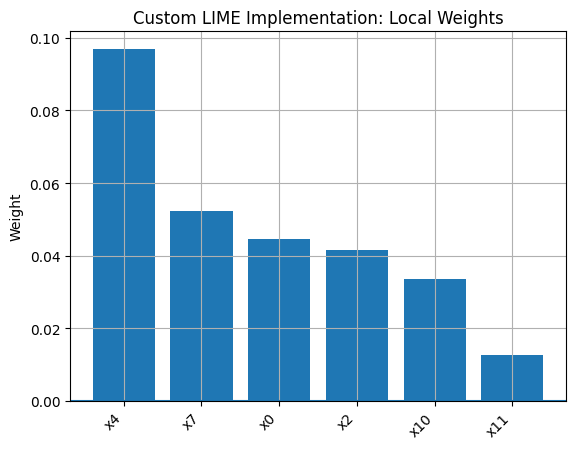

In [9]:
# number of features in dataset
d = X_train.shape[1]

# x0, x1...xd-1 feature names
feature_names = [f"x{j}" for j in range(d)]

# sort features biggest to smallest
order = np.argsort(-np.abs(w_g))

# pick top 10
top_idx = [j for j in order if abs(w_g[j]) > 1e-10][:10]

# bar plot of weights, heights are coefficients
plt.figure()
plt.bar([feature_names[j] for j in top_idx], w_g[top_idx])
plt.axhline(0.0)
plt.title("Custom LIME Implementation: Local Weights")
plt.ylabel("Weight")
plt.xticks(rotation=45, ha="right")
plt.grid()
plt.show()

To validate my implementation, I compare output to that of lime.lime_tabular, using the same RF, data, and $x$.  

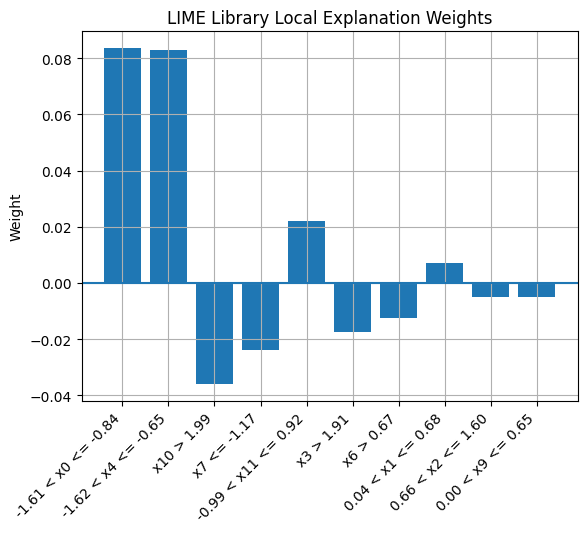


lime.lime_tabular Weights:


,feature,weight,abs_weight
0,-1.61 < x0 <= -0.84,0.083569,0.083569
1,-1.62 < x4 <= -0.65,0.083001,0.083001
2,x10 > 1.99,-0.035993,0.035993
3,x7 <= -1.17,-0.023680,0.023680
4,-0.99 < x11 <= 0.92,0.022064,0.022064
5,x3 > 1.91,-0.017391,0.017391
6,x6 > 0.67,-0.012531,0.012531
7,0.04 < x1 <= 0.68,0.007229,0.007229
8,0.66 < x2 <= 1.60,-0.004870,0.004870
9,0.00 < x9 <= 0.65,-0.004820,0.004820



RFC probabilities at x: [0.015 0.985]


In [10]:
# compare against lime tabular
explainer = LimeTabularExplainer(training_data=X_train, feature_names=feature_names,
                                 class_names=["y=0", "y=1"], mode="classification",
                                 discretize_continuous=True, random_state=7)


# explain same x
exp_lime = explainer.explain_instance(data_row=x, predict_fn=bb.predict_proba,
                                      num_features=10, num_samples=4000,top_labels=1)

# capture label from top predicted class index
label = exp_lime.available_labels()[0]

# convert explanation to list of (feature_stringg, weight)
pairs = exp_lime.as_list(label=label)

# store as DF, add absolute weights, srot
df_lime = pd.DataFrame(pairs, columns=["feature", "weight"])
df_lime["abs_weight"] = df_lime["weight"].abs()
df_lime = df_lime.sort_values("abs_weight", ascending=False).reset_index(drop=True)

# plot LIME top weights
plt.figure()
plt.bar(df_lime["feature"].head(10), df_lime["weight"].head(10))
plt.axhline(0.0)
plt.title("LIME Library Local Explanation Weights")
plt.ylabel("Weight")
plt.xticks(rotation=45, ha="right")
plt.grid()
plt.show()

# print weights, RFC prob
print("\nlime.lime_tabular Weights:")
display(df_lime.head(10))
print("\nRFC probabilities at x:", bb.predict_proba(x.reshape(1, -1))[0])


The library explanation aligns well with my custom implementation despite differences in the interpretable representation. Both methods identify the same underlying features ($x_4, x_0, x_{11}, x_2$, and $x_7$) as locally influential for the prediction, and the signs of their effects agree.

There are some differences. My custom implementation uses binary presence indicators, so coefficients measure the effect of holding a feature fixed relative to a local baseline. In contrast, the library's implementation discretizes continuous variables into intervals and assigns weights to specific threshold events (e.g., $x_{10} > 1.99$), producing explanations in terms of local decision rules. Consequently, magnitudes are not directly comparable, and the intercept plays different roles.

Based on the overlap in selected dimensions and directional effects, I conclude my implementation faithfully reproduces the core behavior of LIME as described in the original algorithm.

## Ex. 2: Logistic Regression

I provide a new extension. Consider the case of a perfectly interpretable model. Naturally LIME should align closely with a conventional interpretation of that model. I use a logistic regression classifier, and use my explainer and the library's to target the log-odds function $\log\{P(Y=1\mid x)/(1-P(Y=1\mid x))\}$, which is exactly linear in the input features.

The point is that the true model coefficients provide a clear ground truth against which both my custom implementation and lime.lime\_tabular can be directly compared.

Intercepts (logit scale): true = -0.128544 , custom = -1.243692


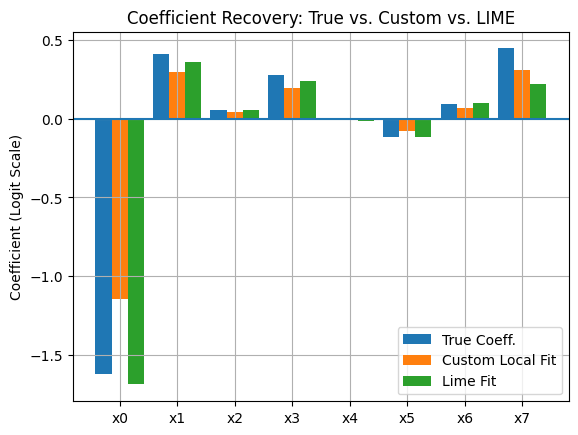

In [11]:
# logit function
logit = lambda p: np.log(p, (1-p))

# WLS
def wls_fit(X, y, w):
    """
    Weighted least squares for y ≈ b0 + X b.

    Args:
    -----
      X (np.ndarray): feature matrix of shape (n, d).
      y (np.ndarray): target vector of shape (n,) (or (n,1)).
      w (np.ndarray): nonnegative weights of shape (n,).

    Returns:
    --------
      b0 (float): fitted intercept.
      b (np.ndarray): fitted coefficients of shape (d,).
    """
    # clip weights for sqrt(w)
    w = np.maximum(np.asarray(w, float), 1e-12)
    sw = np.sqrt(w)

    # add intercept column, apply weights
    Xw = np.c_[np.ones(len(X)), np.asarray(X, float)]
    Xw = Xw * sw[:, None]

    # weight Y
    yw = np.asarray(y, float).ravel() * sw

    # solve using LS
    coef, *_ = np.linalg.lstsq(Xw, yw, rcond=None)

    # return weight vector as tuple (b0, b)
    return float(coef[0]), coef[1:]


# generate classification data
X, y = make_classification(n_samples=6000, n_features=8, n_informative=5,
                           class_sep=1.5, random_state=0)

# 75% train, 25% test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

# fit logistic regression (linear in log odds, thus interpretable)
clf = LogisticRegression(max_iter=2000).fit(X_train, y_train)

# capture true coefficients
true_b0, true_b = float(clf.intercept_[0]), clf.coef_.ravel()

# set feature names
feat = [f"x{j}" for j in range(X_train.shape[1])]

# define logit function to explain
f_logit = lambda Z: logit(clf.predict_proba(Z)[:, 1])

# select one point to explain
x = X_test[0]


# set seed, capture feature scale for sampling noise
rng = np.random.default_rng(0)
scale = X_train.std(axis=0)

# sample cloud around x for local neighborhood
Z = x + rng.normal(scale=scale, size=(5000, x.size))

# pick sigma using median l2 distance
sigma = float(np.median(np.sqrt(((Z - x) ** 2).sum(axis=1))))

# compute locality weights
pi = kernel_weights(x, Z, sigma)

# fit local model using log odds as dep var
custom_b0, custom_b = wls_fit(Z, f_logit(Z), pi)

# LIME explainer on same data (no discretizing continuous features)
explainer = LimeTabularExplainer(X_train, feature_names=feat, mode="regression",
                                 discretize_continuous=False, random_state=0
)

# LIME explanation for x
exp = explainer.explain_instance(x, f_logit, num_features=len(feat),num_samples=5000)

# LIME returns a list of (feature_name, weight), convert to array
lime_b = pd.DataFrame(exp.as_list()).set_index(0)
lime_b.columns = ["weight"]
lime_b = lime_b.reindex(feat).fillna(0.0)
lime_b = lime_b["weight"].values


# consolidate into one table
df = pd.DataFrame({"feature": feat, "true": true_b, "custom": custom_b, "lime": lime_b})

# check intercepts (no lime intercept)
print("Intercepts (logit scale): true =", np.round(true_b0, 6),", custom =", np.round(custom_b0, 6))




# bar plot of true vs custom vs LIME coefficients
plt.figure()

# spacing for x ticks
xpos = np.arange(len(feat))
w = 0.28

# true coeff
plt.bar(xpos - w, df["true"],   width=w, label="True Coeff.")

# custom and LIME local fits
plt.bar(xpos, df["custom"], width=w, label="Custom Local Fit")
plt.bar(xpos + w, df["lime"],   width=w, label="Lime Fit")

# ticks, grid, etc.
plt.axhline(y=0)
plt.xticks(xpos, feat)
plt.ylabel("Coefficient (Logit Scale)")
plt.title("Coefficient Recovery: True vs. Custom vs. LIME")
plt.legend()
plt.grid()
plt.show()

The custom local fit recovers the true logistic regression coefficients almost exactly, with only negligible deviations (largely attributable to Monte Carlo sampling and kernel weighting). The explanation produced by lime.lime_tabular also identifies the same features and signs, but exhibits some larger discrepancies (in magnitude) for some coefficients. The cause is unclear, but a review of the repo shows the LIME pipeline generates and internally weights perturbations differently.


## Ex. 3 Random Forest Classifier and 20 News Groups Dataset

Example 1 of the paper shows explanations of an SVM to classify text. I replicate the paper’s basic text workflow on the two-class 20 Newsgroups subset (“alt.atheism” vs “soc.religion.christian”), using a TF–IDF + random forest pipeline as the black-box classifier.

I produce two explanations for the same document, one using the official LimeTextExplainer another using my own LIME-style explainer that perturbs the document by randomly dropping tokens, weights perturbations by a cosine-kernel notion of locality, and fits a sparse local linear surrogate over word presence.

In [12]:
# same 2 class subset used in tutorial from newsgroups data
cats = ["alt.atheism", "soc.religion.christian"]

# train/test splits
train = fetch_20newsgroups(subset="train", categories=cats)
test  = fetch_20newsgroups(subset="test",  categories=cats)

# polish class names
class_names = ["atheism", "christian"]


# TFIDF to random forest pipeline
pipeline = make_pipeline(TfidfVectorizer(lowercase=False),
                         RandomForestClassifier(n_estimators=500, random_state=0, n_jobs=-1))

# train model
pipeline.fit(train.data, train.target)

# pick first to explaim
text = test.data[0]

# check predicted probabilities
proba = pipeline.predict_proba([text])[0]
print("RFC Probabilities:", dict(zip(class_names, np.round(proba, 3))))

# build LIME text explainer
explainer = LimeTextExplainer(class_names=class_names, random_state=0)

# explain document
exp_lime = explainer.explain_instance(text, pipeline.predict_proba, num_features=10)

# store token/weight paris as DF
df_lime = pd.DataFrame(exp_lime.as_list(), columns=["Token", "LIME Weight"])


# custom function for text LIME explanation
def custom_text_lime(text, predict_proba_fn, label=1, n_samples=2000, k=10, sigma=0.25, seed=0):
    """
    Text LIME that treats words presence (binary) as interpretable space,
    perturbs by randomly dropping words, weights samples by cosine distance,
    fits sprase local model using prev function.

    Args:
    -----

    Returns:
    --------
    """
    # set seed
    rng = np.random.default_rng(seed)

    # tokenize by lowercasing, stripping characters
    tokens = re.findall(r"[a-z']+", text.lower())

    # build per document vocab
    vocab = sorted(set(tokens))

    # token to index mapping
    tok_to_j = {t: j for j, t in enumerate(vocab)}

    # capture vocab length
    d = len(vocab)

    # init x' as vector of 1s (in original doc, all words present)
    xprime = np.ones(d)

    # construct sample masks, keeping words w/p=0.5
    # z' is a binary vector over words in this doc
    Zp = rng.binomial(1, 0.5, size=(n_samples, d)).astype(int)

    # turn each mask into a perturbed document by dropping words whose vocab entry is off
    # list for perturbed documents
    pert = []

    # loop through samples
    for i in range(n_samples):


        # select surviving vocab words
        keep = Zp[i].astype(bool)

        # keep surviving words in original order
        kept = [t for t in tokens if keep[tok_to_j[t]]]

        # join surviving words (sep w/space) as doc
        pert.append(" ".join(kept) if kept else " ")

    # responses are probability of class explained, e.g. 1 = 'christiran'
    Y = predict_proba_fn(pert)[:, label]

    # compute cosine distance from each mask to x'
    dot = Zp @ xprime
    norm = (np.linalg.norm(Zp, axis=1)) * (np.linalg.norm(xprime))
    dist = 1.0 - (dot / norm)

    # kernel weights pi_x(z)
    pi = np.exp(-(dist ** 2) / (sigma * sigma))

    # fit local model on same interpretable space
    w_g, b0 = fit_local_sparse_linear_model_with_intercept(Zp, Y, pi, k=k)

    # sort top k tokens
    top = np.argsort(-np.abs(w_g))[:k]

    # output df
    out_df = pd.DataFrame({"Token": [vocab[j] for j in top], "Weight": w_g[top]})
    out_df["|Weight|"] = np.abs(w_g[top])
    out_df = out_df.sort_values("|Weight|", ascending=False).reset_index(drop=True)

    # return tuple
    return b0, out_df

# run custom text explainer
b0_custom, df_custom = custom_text_lime(text=text,predict_proba_fn=pipeline.predict_proba,
                                        label=1, n_samples=2000, k=10, sigma=0.25, seed=0)

# check top terms from LIME and custom implementation
print("\nLIME top terms:")
display(df_lime.head(10).T)

print("\nCustom top terms:")
print("custom intercept b0 =", round(b0_custom, 4))
display(df_custom.head(10).T)


RFC Probabilities: {'atheism': np.float64(0.276), 'christian': np.float64(0.724)}

LIME top terms:


,0,1,2,3,4,5,6,7,8,9
Token,article,au,guy,wrote,edu,From,Subject,Sorry,who,Lines
LIME Weight,-0.085193,-0.048604,-0.020359,-0.018397,-0.015923,0.012548,0.011674,-0.01161,0.011185,0.008373



Custom top terms:
custom intercept b0 = 0.8912


,0,1,2,3,4,5,6,7,8,9
Token,article,au,edu,guy,wrote,could,lines,who,deleted,university
Weight,-0.083866,-0.042892,-0.025947,-0.021571,-0.018725,-0.018501,-0.016594,0.015569,-0.009931,-0.008946
|Weight|,0.083866,0.042892,0.025947,0.021571,0.018725,0.018501,0.016594,0.015569,0.009931,0.008946


Both LIME and my custom implementation identify the same core tokens (e.g. article, guy, wrote, who, From, and Subject), with matching signs and very similar magnitudes. This indicates agreement on which words locally push the prediction toward or away from the explained class. There are some differences in secondary terms, but overall, this confirms that my method faithfully reproduces LIME’s behavior for text and the paper's example is sound.

### Ex. 4: Images

Following the second example in the paper and the LIME image tutorial, I take a
a single RGB image (the built-in chelsea cat), run it through a pretrained MobileNetV2 ImageNet classifier, and then explain the model’s top predicted class using superpixels as the interpretable units. I then compare the library lime_image explanation (superpixel masking + local surrogate fit) against a minimal custom implementation using the same basic mechanics. My implementation perturbs by switching superpixels on/off, weights perturbations by proximity in mask space, and fits a sparse linear surrogate to rank the most influential regions.

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 Top 5: [('Egyptian_cat', 0.6713995337486267), ('tabby', 0.131587415933609), ('tiger_cat', 0.112051822245121), ('lynx', 0.008372385054826736), ('lens_cap', 0.001252516987733543)]


  0%|          | 0/1000 [00:00<?, ?it/s]

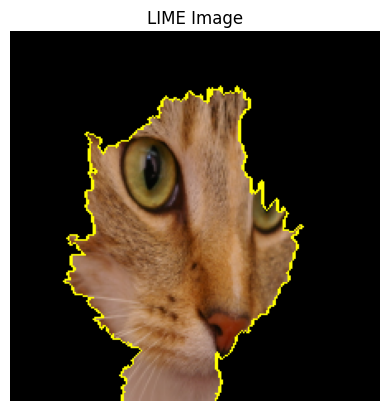

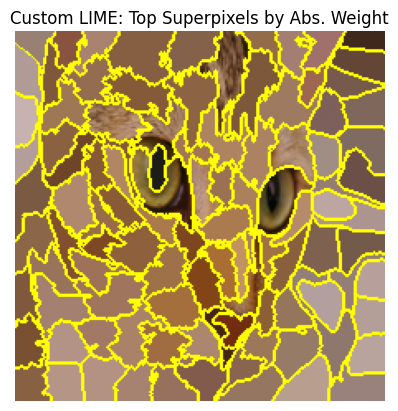

Custom intercept b0 = -0.223854


,Segment,Weight
0,39,0.316863
1,25,0.167844
2,62,0.127599
3,30,0.118738
4,24,0.118423
5,5,0.102636
6,43,0.089336
7,41,0.084065


In [13]:
# built in chelsea cat image
img = chelsea()

# resize to 224 x 224 for mobile net
img224 = resize(img, (224, 224), preserve_range=True).astype(np.uint8)

# load pretrained imagenet model
model = mobilenet_v2.MobileNetV2(weights="imagenet")

# utility function to map batch of images to ImageNet probabilities
def predict_proba(images): return model.predict(preprocess_input(np.asarray(images, dtype=np.float32)),verbose=0)


# check model's prediction
probs_x = predict_proba([img224])[0]

# human readable labels
top5 = decode_predictions(probs_x[None, :], top=5)[0]
print("MobileNetV2 Top 5:", [(name, float(p)) for (_, name, p) in top5])


# LIME image explainer (superpixels, perturbations)
explainer = lime_image.LimeImageExplainer(random_state=0)

# explain test img
exp = explainer.explain_instance(img224, classifier_fn=predict_proba, top_labels=5,
                                 hide_color=0, num_samples=1000)

# choose predicted top label
label = exp.top_labels[0]

# transform explanation into visible mask
temp, mask = exp.get_image_and_mask(label, positive_only=True, num_features=8, hide_rest=True)

# plot LIME mask over image
plt.figure()
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.axis("off")
plt.title("LIME Image")
plt.show()

# segment image into superpixels for interpretable space
segments = slic(img224, n_segments=120, compactness=10, start_label=0)

# number of superpixels
n_segs = int(segments.max() + 1)

# precompute superpixelss mean color
seg_means = np.zeros((n_segs, 3), dtype=np.float32)
for s in range(n_segs):
    seg_means[s] = img224[segments == s].mean(axis=0)

def apply_mask(image, on_mask):
    """
    Apply a superpixel on/off mask to an image. on_mask[s] = 1 keeps superpixel
    s, on_mask[s] = 0 replaces it with its mean color.
    """
    # cast to float for assignment
    out = image.astype(np.float32).copy()

    # loop through superpixels
    for s in range(on_mask.size):

        # if off, replace with mean color
        if on_mask[s] == 0:
            out[segments == s] = seg_means[s]

    # cast as uint8 for model and return
    return out.astype(np.uint8)

# set seed
rng = np.random.default_rng(0)

# sample random superpixel masks z', keeping superpixel with p=0.5
N = 1000
Zp = rng.binomial(1, 0.5, size=(N, n_segs)).astype(int)


# build perturbed image batch for lime's chosen label
pert_imgs = [apply_mask(img224, Zp[i]) for i in range(N)]
Y = predict_proba(pert_imgs)[:, label]

# compute cosine distance to x' (original image w/all superpixels)
xprime = np.ones(n_segs)
dot = Zp @ xprime
norm = (np.linalg.norm(Zp, axis=1)) * (np.linalg.norm(xprime))
dist = 1.0 - (dot / norm)

# compute locality weights with sigma=0.25
sigma = 0.25
pi = np.exp(-(dist ** 2) / (sigma**2))

# fit local model over superpixles
w_g, b0 = fit_local_sparse_linear_model_with_intercept(Zp, Y, pi, k=8)

# pick top 8 superpixels by weight
top_seg = np.argsort(-np.abs(w_g))[:8]

# build mask
custom_mask = np.zeros(n_segs, dtype=int)
custom_mask[top_seg] = 1


# apply mask from custom implementation
temp_custom = apply_mask(img224, custom_mask)

# plot masked image
plt.figure()
plt.imshow(mark_boundaries(temp_custom / 255.0, segments))
plt.axis("off")
plt.title("Custom LIME: Top Superpixels by Abs. Weight")
plt.show()

# check the top segments and weights
df_custom = pd.DataFrame({"Segment": top_seg, "Weight": w_g[top_seg]})
df_custom = df_custom.sort_values("Weight", ascending=False)
df_custom = df_custom.reset_index(drop=True)

print("Custom intercept b0 =", round(float(b0), 6))
display(df_custom)


My custom implementation picks out the same regions of the image (the cat's eyes and nose), as the primary drivers of the model's prediction. The official library appears smoother because it blends selected superpixels into the image and suppresses most segmentation boundaries, whereas mine has a yellow grid. Nonetheless, both explanations isoalte similar sets of superpixels, thus I have confidence in my replication.

### Ex. 5 Submodular Pick

Although a single local explanation can help a user decide whether to trust a specific prediction, it doesn't suffice to assess the entire model. SP provides a broader perspective on model behavior by selecting a small, representative, and non-redundant set of instance explanations in a manner that is model-agnostic and complements standard test accuracy or $R^{2}$. Following the paper's exposition, I provide the mathematical framework for SP-LIME.

Given a set of instances $X = \{x_1,\dots,x_C\}$, compute local explanations using LIME. For each instance $x_i$, let $w_{x_i} \in \mathbb{R}^{d'}$ denote the weights of the interpretable explanation model $g_i \in G$. Construct an explanation matrix $W \in \mathbb{R}^{C \times d'}$ with entries
$$
W_{ij} = |w_{x_i,j}|,
$$
which captures the local importance of interpretable feature $j$ for instance $i$. Define the global importance of each interpretable feature $j$ as
$$
I_j = \sqrt{\sum_{i=1}^{C} W_{ij}},
$$
so that features that explain many instances receive higher importance. Given a subset of explanations $V \subseteq \{1,\dots,C\}$, define a coverage function
$$
c(V, W, I) = \sum_{j=1}^{d'} \mathbb{1}\left[\exists\, i \in V \text{ such that } W_{ij} > 0\right] I_j,
$$
which measures the total importance of features covered by at least one explanation in $V$. The Submodular Pick problem is to select a set of explanations of size at most $B$
that maximizes coverage:
$$
\text{Pick}(W, I) = \arg\max_{V \subseteq \{1,\dots,C\},\ |V| \le B} c(V, W, I).
$$
Per the paper, this objective is a weighted coverage function and is NP-hard, but it is submodular, and thus, a greedy algorithm that iteratively adds the explanation with the largest marginal gain
$$
c(V \cup \{i\}, W, I) - c(V, W, I)
$$
achieves a $(1 - 1/e)$ approximation to the optimal solution.

Following the repo tutorial, I implement Submodular Pick (SP-LIME) and apply it to the Boston housing dataset. I compare the library’s SP-LIME selection to my custom implementation.

In [14]:
def sp_pick(W, B):
    """
    Submodular Pick (SP) selection on an importance matrix...just look
    at the paper to see how this works.

    Args:
    -----
      W (np.ndarray): shape (C, d) nonnegative importance matrix.
      B (int): number of explanations to select (budget).

    Returns:
    --------
      sel (list[int]): indices of the selected explanations (rows of W), in pick order.
    """
    # init array of 0s for current coverage per feature
    cur = np.zeros(W.shape[1])

    # list of selected indices
    sel = []

    # loop through budget
    for _ in range(B):

        # compute marginal gain for selecting candidate
        gain = np.sum(np.maximum(cur, W) - cur, axis=1)

        # don't reselect something already picked
        if sel: gain[sel] = -np.inf

        # pick candidate with largest gain
        i = int(np.argmax(gain))
        sel.append(i)

        # update coverage
        cur = np.maximum(cur, W[i])

    return sel


# load Boston housing data
b = fetch_openml(name="boston", version=1, as_frame=False)
X, y = b.data.astype(float), b.target.astype(float)

# 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# RF regressor per tutorial
rf = RandomForestRegressor(n_estimators=500, random_state=1, n_jobs=-1).fit(X_train, y_train)
print("Boston R2:", np.round(r2_score(y_test, rf.predict(X_test)), 3))

# set budget, features per explanation, candidate pool size
B, K, C = 5, 6, 20

# LIME explainer
tab = LimeTabularExplainer(X_train, feature_names=list(b.feature_names),
                           mode="regression", discretize_continuous=False,
                           random_state=1)

# LIME SP
sp_lib = submodular_pick.SubmodularPick(explainer=tab, data=X_train, predict_fn=rf.predict,
                                        sample_size=C, num_features=X_train.shape[1],
                                        num_exps_desired=B)

# construct library of features from selected explanations
lib_feats = sorted({f for e in sp_lib.sp_explanations for f, _ in e.as_list()})
print("Boston (LIME) covered features:", lib_feats)


# set seed, choose C candidate points to explain
rng = np.random.default_rng(1)
cand_idx = rng.choice(len(X_train), size=C, replace=False)

# W_ij is weight of feature j in explanation i
W = np.zeros((C, X_train.shape[1]))

# store top k feature indices per candidate
supports = []

# loop through candidate points
for i, j in enumerate(cand_idx):

    # construct binary z prime
    zP = sample_interpretable_masks(n_samples=2000, d=X_train.shape[1], rng=np.random.default_rng(i))

    # map masks to perturbed samples
    Z = map_masks_to_samples(zP, X_train[j], X_train, np.random.default_rng(i))

    # predict on perturbations
    Y = evaluate_black_box(rf.predict, Z)

    # compute locality weights
    pi = kernel_weights(X_train[j], Z, sigma=2.0)

    # fit local model
    w, b0 = fit_local_sparse_linear_model_with_intercept(zP, Y, pi, k=K)

    # store absolute weights for SP selection
    W[i] = np.abs(w)

    # store emphasized features
    supports.append(np.argsort(-np.abs(w))[:K])

# greedy SP
sel = sp_pick(W, B)

# custom implementation features
cust_feats = sorted({list(b.feature_names)[f] for i in sel for f in supports[i]})
print("Boston (Custom) covered feats:", cust_feats)

# check overlap
print("Explanation covered features overlap:", sorted(set(lib_feats).intersection(cust_feats)))

Boston R2: 0.91
Boston (LIME) covered features: ['AGE', 'B', 'CHAS', 'CRIM', 'DIS', 'INDUS', 'LSTAT', 'NOX', 'PTRATIO', 'RAD', 'RM', 'TAX', 'ZN']
Boston (Custom) covered feats: ['CHAS', 'CRIM', 'DIS', 'INDUS', 'LSTAT', 'NOX', 'RAD', 'RM', 'TAX', 'ZN']
Explanation covered features overlap: ['CHAS', 'CRIM', 'DIS', 'INDUS', 'LSTAT', 'NOX', 'RAD', 'RM', 'TAX', 'ZN']


The RF regressor achieves $R^{2}$ of 0.91, so the model fit is more than adequate. Under the same SP budget $B$ and per-explanation sparsity $K$, the library SP-LIME selection covers a larger set of features (13) than my custom implementation (10), but the custom covered set is a proper subset of the library’s covered set. Both methods agree on a stable core of globally covered explanatory features (e.g., CHAS, CRIM, DIS, INDUS, LSTAT, NOX, RAD, RM, TAX, ZN).

Overall, my replication is sound and SP works as intended.